In [8]:
import pandas as pd
import glob
dataframes={}
files=glob.glob("/content/*.csv")
for file in files:
  df=pd.read_csv(file)
  name=file.split("/")[-1]
  dataframes[name]=df
  print(f"{name} Loaded Sucessfully, shape: {df.shape}")

insurance_data.csv Loaded Sucessfully, shape: (27, 2)
test.csv Loaded Sucessfully, shape: (418, 11)
train.csv Loaded Sucessfully, shape: (891, 12)


In [9]:
train_df=dataframes['train.csv']
test_df=dataframes['test.csv']
insurance_df=dataframes['insurance_data.csv']

In [14]:
import pandas as pd
import numpy as np
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

files = glob.glob("/content/*.csv")

for file in files:
    print("\nProcessing:", file)

    df = pd.read_csv(file)
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col])

    possible_targets = ['Survived', 'Attrition', 'Purchased', 'Outcome']
    target = None

    for col in possible_targets:
        if col in df.columns:
            target = col
            break

    if target is None:
        print("No target column → Skipping file")
        continue

    X = df.drop(target, axis=1)
    y = df[target]

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Target:", target)
    print("Accuracy:", accuracy_score(y_test, y_pred))


Processing: /content/insurance_data.csv
No target column → Skipping file

Processing: /content/test.csv
No target column → Skipping file

Processing: /content/train.csv
Target: Survived
Accuracy: 0.8100558659217877


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[90 15]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



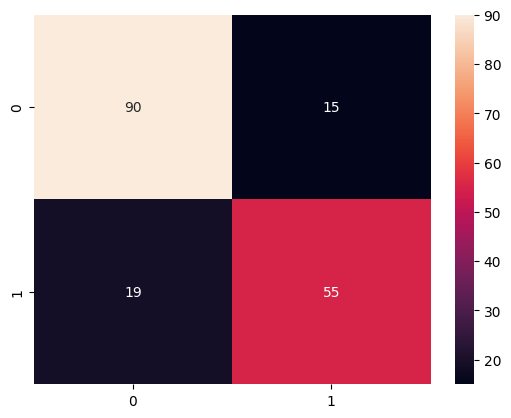

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()